In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
scenarios = pd.read_csv('X_frequencies.csv')
scenarios.head()

,X,T_freq,L_freq
0,1,0.0,1.0
1,2,0.0,2.0
2,3,0.0,3.0
3,4,0.0,4.0
4,5,0.0,5.0


In [3]:
X = list(range(1,48))

In [4]:
cutoffs = [15,30,45,60]

In [5]:
accessdf = pd.DataFrame() 
for i in X:
    for t in cutoffs:
        filename = './FrequencyMatrix_ByPrecinct/Pyramid_ByPrecinct/TOD4_X'+str(i)+'_Pyramid_T'+str(t)+'_jobs.csv'
        mydf = pd.read_csv(filename)
        mydf['cutoff'] = t
        mydf['X'] = i
        accessdf = accessdf.append(mydf)
accessdf.head()

,locality,Jobs,cutoff,X
0,BUSBY,2295.984982,15,1
1,MILLER,3283.443851,15,1
2,CASULA,1112.603664,15,1
3,CARTWRIGHT,5051.213574,15,1
4,HECKENBERG,1464.038413,15,1


In [6]:
len(accessdf)

7896

In [7]:
accessdf = accessdf.merge(scenarios, how='left', on='X')
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq
0,BUSBY,2295.984982,15,1,0.0,1.0
1,MILLER,3283.443851,15,1,0.0,1.0
2,CASULA,1112.603664,15,1,0.0,1.0
3,CARTWRIGHT,5051.213574,15,1,0.0,1.0
4,HECKENBERG,1464.038413,15,1,0.0,1.0


In [8]:
accessdf.to_csv('Access_AllScenarios_Pyramid.csv', index=False)

In [9]:
accessdf.loc[accessdf['locality']=='ROSSMORE']['Jobs'].unique()

array([nan])

### No Tways, Local routes with varying frequencies

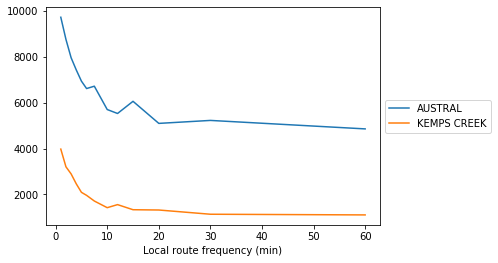

In [10]:
local15 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==15)]
ax = local15.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Local route frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


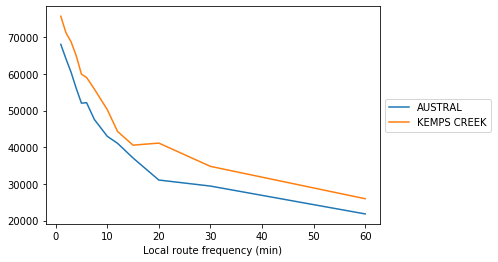

In [11]:
local30 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==30)]
ax = local30.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Local route frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


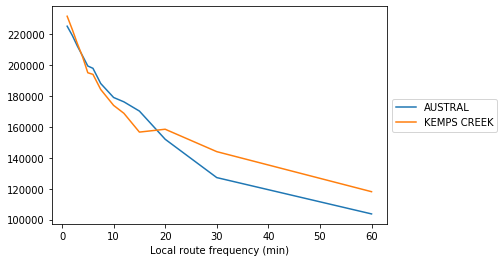

In [12]:
local45 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==45)]
ax = local45.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Local route frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


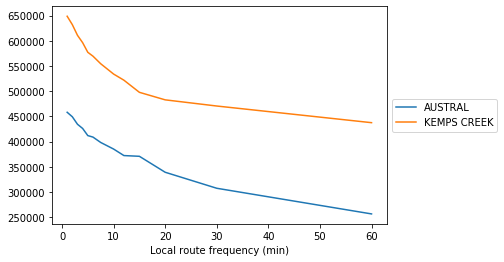

In [13]:
local60 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==60)]
ax = local60.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Local route frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


### No local routes, Tways with varying frequencies

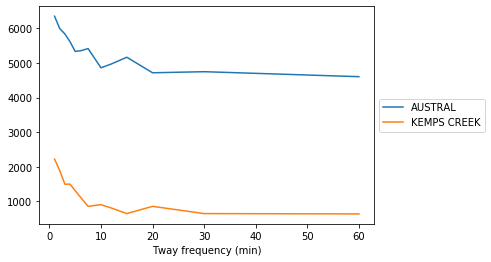

In [14]:
tway15 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==15)]
ax = tway15.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Tway frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


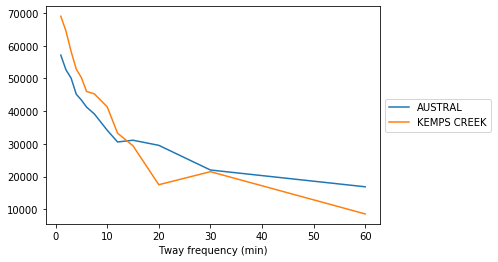

In [15]:
tway30 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==30)]
ax = tway30.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Tway frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


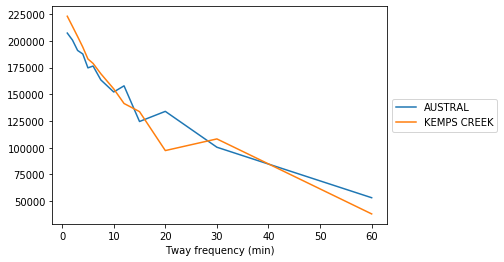

In [16]:
tway45 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==45)]
ax = tway45.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Tway frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


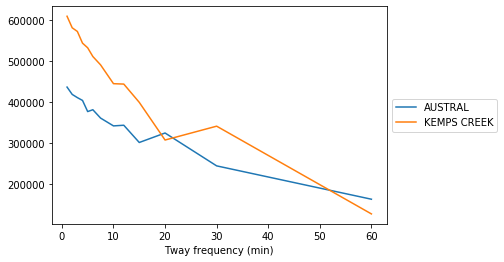

In [17]:
tway60 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==60)]
ax = tway60.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs').plot()
ax.set_xlabel("Tway frequency (min)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


### Tways and local routes with same frequencies

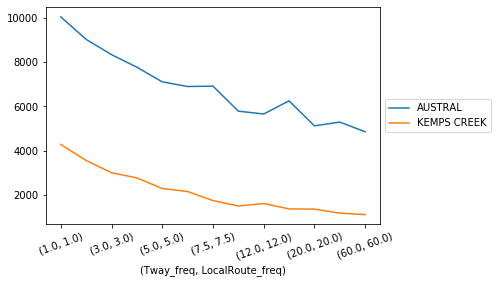

In [18]:
diagonal15 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==15)]
ax = diagonal15.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot(rot=20)
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


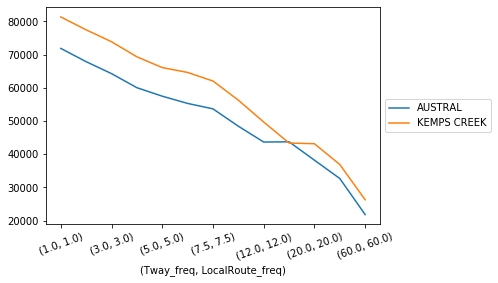

In [19]:
diagonal30 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==30)]
ax = diagonal30.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot(rot=20)
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


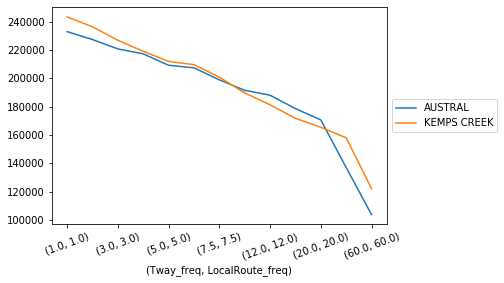

In [20]:
diagonal45 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==45)]
ax = diagonal45.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot(rot=20)
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


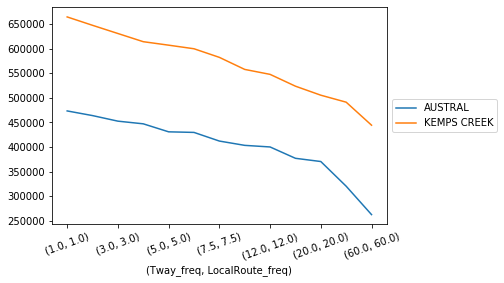

In [21]:
diagonal60 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==60)]
ax = diagonal60.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot(rot=20)
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


### Tways varying, local routes fixed at 1min

In [22]:
xrange_t = [27]+list(range(40,44))

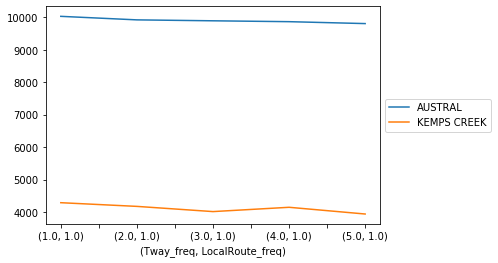

In [23]:
tvar_lfix_15 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==15)]
ax = tvar_lfix_15.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


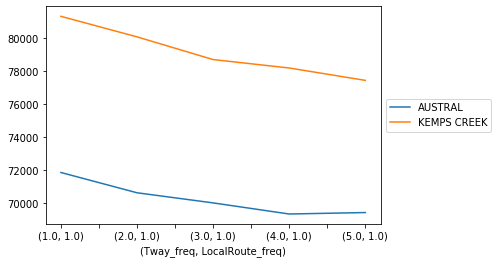

In [24]:
tvar_lfix_30 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==30)]
ax = tvar_lfix_30.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


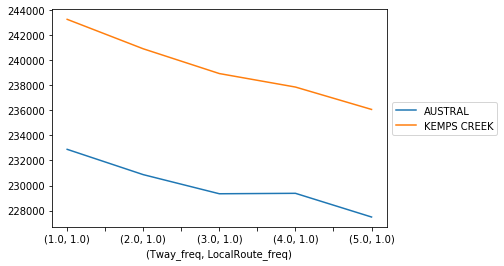

In [25]:
tvar_lfix_45 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==45)]
ax = tvar_lfix_45.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


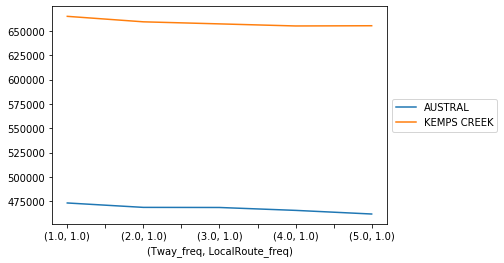

In [26]:
tvar_lfix_60 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==60)]
ax = tvar_lfix_60.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


### Tways fixed at 1min, local routes varying

In [27]:
xrange_l = [27]+list(range(44,48))

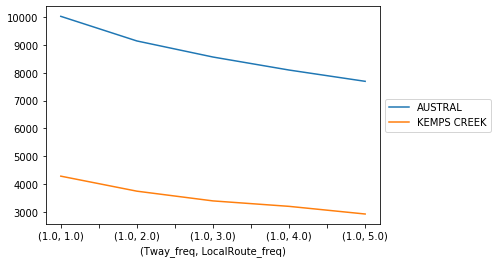

In [28]:
tfix_lvar_15 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==15)]
ax = tfix_lvar_15.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


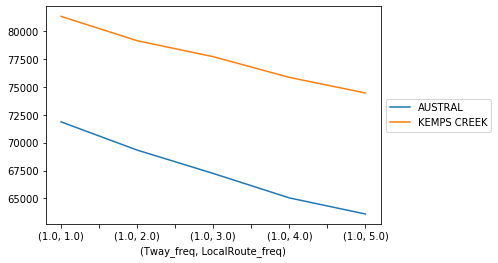

In [29]:
tfix_lvar_30 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==30)]
ax = tfix_lvar_30.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


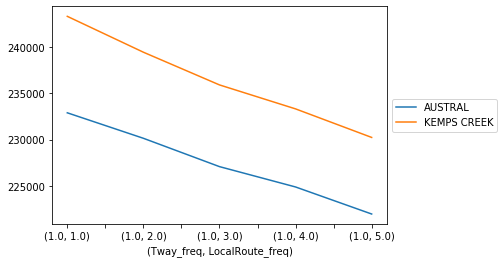

In [30]:
tfix_lvar_45 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==45)]
ax = tfix_lvar_45.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


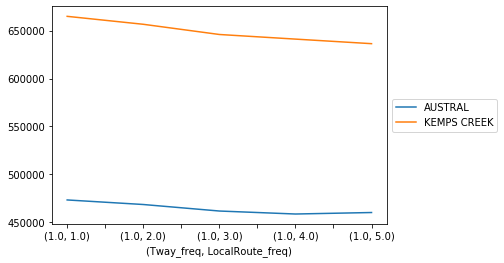

In [31]:
tfix_lvar_60 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK']))
                       & (accessdf['cutoff']==60)]
ax = tfix_lvar_60.drop(['cutoff','X'], axis=1).pivot_table(index=['T_freq','L_freq'],columns='locality',values='Jobs').plot()
ax.set_xlabel("(Tway_freq, LocalRoute_freq)")
ax.legend(loc='center left',bbox_to_anchor=(1.0, 0.5))

